Total samples: 6000  Features: 6
Training samples: 4800  Testing samples: 1200
max_depth = 2  Accuracy = 0.6775
max_depth = 3  Accuracy = 0.6783
max_depth = 4  Accuracy = 0.6875
max_depth = 5  Accuracy = 0.6908
max_depth = 6  Accuracy = 0.6825
max_depth = 8  Accuracy = 0.6733
Selected max_depth = 3
Accuracy: 0.6783
Number of leaves: 8
Confusion Matrix:
[[416 155]
 [231 398]]
              precision    recall  f1-score   support

Non-Boundary       0.64      0.73      0.68       571
    Boundary       0.72      0.63      0.67       629

    accuracy                           0.68      1200
   macro avg       0.68      0.68      0.68      1200
weighted avg       0.68      0.68      0.68      1200

Feature Importances:
Intensity = 0.0
Gradient = 0.0
LocalMean = 0.0443
LocalStd = 0.9557
Laplacian = 0.0
Range = 0.0
|--- LocalStd <= 0.06
|   |--- LocalStd <= 0.01
|   |   |--- LocalStd <= 0.00
|   |   |   |--- class: 0
|   |   |--- LocalStd >  0.00
|   |   |   |--- class: 0
|   |--- LocalStd 

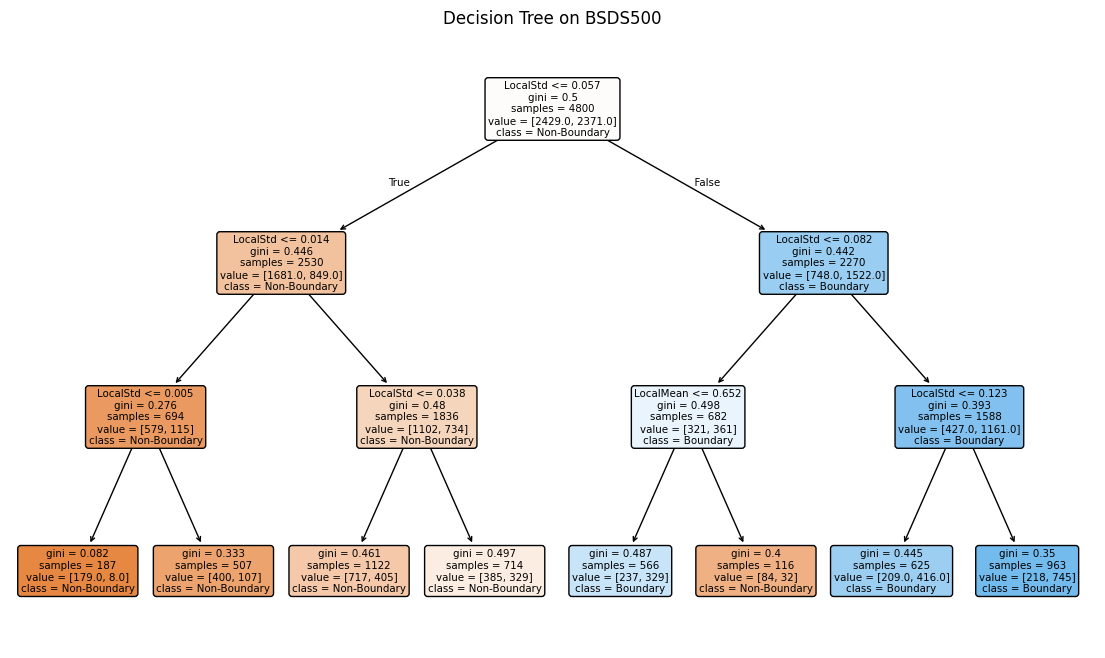

In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.io import loadmat
from scipy.ndimage import uniform_filter, sobel, laplace, maximum_filter, minimum_filter
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import kagglehub

path = kagglehub.dataset_download("balraj98/berkeley-segmentation-dataset-500-bsds500")

images = sorted(glob.glob(path + "/**/*.jpg", recursive=True))
gtmap = {}
for m in glob.glob(path + "/**/*.mat", recursive=True):
    gtmap[os.path.basename(m)[:-4]] = m

names = ["Intensity", "Gradient", "LocalMean", "LocalStd", "Laplacian", "Range"]


def get_features(f):
    g = np.array(Image.open(f).convert("L"), dtype=float) / 255.0
    gx = sobel(g, axis=0)
    gy = sobel(g, axis=1)
    grad = np.sqrt(gx * gx + gy * gy)
    mean = uniform_filter(g, 5)
    std = np.sqrt(np.abs(uniform_filter(g * g, 5) - mean * mean))
    lap = np.abs(laplace(g))
    rng = maximum_filter(g, 3) - minimum_filter(g, 3)
    F = np.stack([g, grad, mean, std, lap, rng], axis=2)
    return F.reshape(-1, 6), g.shape


def get_labels(name, shape):
    d = loadmat(gtmap[name])["groundTruth"]
    b = np.zeros(shape)
    for i in range(d.shape[1]):
        b = b + d[0, i]["Boundaries"][0, 0]
    return (b > 0).astype(int).reshape(-1)


def build_dataset(n_images, per_class):
    X = []
    Y = []
    for f in images[:n_images]:
        name = os.path.basename(f)[:-4]
        if name not in gtmap:
            continue
        F, shape = get_features(f)
        L = get_labels(name, shape)
        pos = np.where(L == 1)[0]
        neg = np.where(L == 0)[0]
        k = min(per_class, len(pos), len(neg))
        if k == 0:
            continue
        pos = np.random.choice(pos, k, replace=False)
        neg = np.random.choice(neg, k, replace=False)
        idx = np.concatenate([pos, neg])
        X.append(F[idx])
        Y.append(L[idx])
    return np.vstack(X), np.concatenate(Y)


np.random.seed(1)
X, y = build_dataset(30, 100)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)

print("Total samples:", len(X), " Features:", X.shape[1])
print("Training samples:", len(Xtr), " Testing samples:", len(Xte))

for d in [2, 3, 4, 5, 6, 8]:
    m = DecisionTreeClassifier(criterion="gini", max_depth=d, random_state=42)
    m.fit(Xtr, ytr)
    print("max_depth =", d, " Accuracy =", round(accuracy_score(yte, m.predict(Xte)), 4))

model = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=42)
model.fit(Xtr, ytr)
pred = model.predict(Xte)

print("Selected max_depth = 3")
print("Accuracy:", round(accuracy_score(yte, pred), 4))
print("Number of leaves:", model.get_n_leaves())
print("Confusion Matrix:")
print(confusion_matrix(yte, pred))
print(classification_report(yte, pred, target_names=["Non-Boundary", "Boundary"]))

print("Feature Importances:")
for i in range(len(names)):
    print(names[i], "=", round(model.feature_importances_[i], 4))

print(export_text(model, feature_names=names))

plt.figure(figsize=(14, 8))
plot_tree(model, feature_names=names, class_names=["Non-Boundary", "Boundary"], filled=True, rounded=True)
plt.title("Decision Tree on BSDS500")
plt.show()
